
# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?



--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
print(users.isna().sum())
print(users.isna().mean() * 100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean() * 100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- city (11.7%), churn_date (88.4%), date en usage (0.125%), duration (55.2%) y length (44.7%).
- Indica qué harías: ¿imputar, eliminar, ignorar?
- users.city: 469 nulos (11.7%). Proporción media — no se elimina. Se investigará si hay un sentinel (?) detrás de estos nulos antes de decidir; probablemente se dejará como nulo o se imputará con "Desconocido", ya que no afecta variables de uso o churn.
users.churn_date: 3534 nulos (88.4%). No es un problema de calidad — es estructural: el nulo indica que el cliente no ha cancelado. No se imputa ni se elimina; se usará para derivar una columna booleana de churn.
usage.date: 50 nulos (0.125%). Proporción mínima, no representativo. Se puede dejar como nulo o eliminar esas filas sin impacto en el análisis.
usage.duration: 22076 nulos (55.2%) y usage.length: 17896 nulos (44.7%). No son errores — son complementarios por diseño: una fila de tipo call tiene duration y nulo en length; una fila de tipo text tiene length y nulo en duration. Se verificará esta hipótesis (MAR respecto a type) en el paso 3.2, y de confirmarse, se dejarán como nulos sin imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
print(users['user_id'].describe())
print(users['age'].describe())

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves: va de 10000 a 13999, sin saltos ni valores negativos o repetidos sospechosos. No presenta sentinels.
- La columna `age` ... tiene un valor mínimo de -999, claramente un sentinel (una edad no puede ser negativa). Esto también explica la media inflada (33.7) y el std anormalmente alto (123.2) comparado con el resto del rango (25%-75% entre 32 y 63 años). Se reemplazará por la mediana en el paso 3.1.

In [13]:
print(usage[['id', 'user_id']].describe())
print(usage[['duration', 'length']].describe())

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000
           duration        length
count  17924.000000  22104.000000
mean       5.202237     52.127398
std        6.842701     56.611183
min        0.000000      0.000000
25%        1.437500     37.000000
50%        3.500000     50.000000
75%        6.990000     64.000000
max      120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves: id es un consecutivo de 1 a 40000 sin duplicados aparentes, y user_id está en el mismo rango que en users (10000-13999), lo cual es coherente. No hay sentinels.
- Las columnas ... duration y length ... ambas tienen mínimo en 0, lo cual es plausible (llamada de 0 minutos registrada, o mensaje vacío) y no un sentinel evidente. El máximo de length (1490) es alto pero no necesariamente inválido — se evaluará como posible outlier en el paso 5.2, no como sentinel.

In [14]:
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()


city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` ... tiene 469 nulos reales (NaN) más 96 registros con el valor "?", que es un sentinel distinto a un nulo. Sumando ambos, el 14.1% de los registros de city no tienen un valor utilizable. El "?" se reemplazará por pd.NA en el paso 3.1 para unificarlo con los nulos reales.
- La columna `plan` ... solo tiene dos categorías (Basico, Premium), sin errores de tipeo, mayúsculas inconsistentes ni valores inesperados. No presenta sentinels.

In [15]:
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` ... solo tiene dos categorías (text, call), bien distribuidas (22092 vs 17908), sin errores ni valores inesperados. No presenta sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- age: valor sentinel -999 (edad imposible), presente como mínimo del describe.
city: valor sentinel "?" en 96 registros (2.4%), distinto de los 469 nulos reales ya identificados.
- ¿Qué acción tomarías?
age: reemplazar -999 por la mediana de la columna (excluyendo el sentinel del cálculo).
city: reemplazar "?" por pd.NA, unificándolo con los nulos reales para tratarlo de forma consistente en el paso de limpieza.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves: la mayoría de los registros se concentran en 2022, 2023 y 2024 (~1300 cada año), consistente con el rango de operación de ConnectaTel. Sin embargo, hay 40 registros con año 2026, lo cual es imposible dado que los datos están registrados solo hasta 2024 — es un error de captura (fecha futura).

In [19]:
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())


2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas: todos los registros válidos caen en 2024, consistente con el periodo de uso analizado. Hay 50 valores nulos (NaN), que ya habíamos identificado en el paso 2.1 (0.125%), sin años inválidos entre los datos parseados correctamente.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí. En reg_date hay 40 registros (1%) con año 2026, una fecha futura imposible dado que el negocio reporta datos únicamente hasta 2024. En date no se encontraron años imposibles, solo los 50 nulos ya conocidos.
- ¿Qué harías con ellas?
- Marcar los 40 registros con año 2026 en reg_date como pd.NA (fecha inválida), ya que no se puede inferir la fecha real de registro y es una proporción baja (1%) que no compromete el análisis. No se imputa con una fecha arbitraria porque distorsionaría el análisis de antigüedad de cliente.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100))


type
call     0.000000
text    99.927576
Name: duration, dtype: float64


In [24]:
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100))


type
call    99.932991
text     0.000000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`: 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

In [30]:

user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']] = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].fillna(0)

# Verificar cambios
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

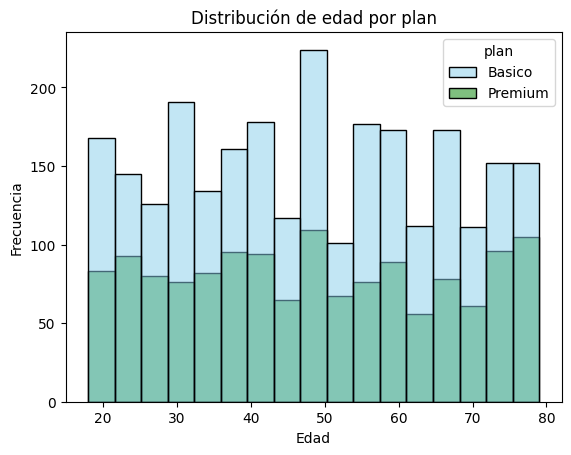

In [31]:

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], multiple='layer')
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Distribución de age aproximadamente uniforme/simétrica entre 18 y 79 años, sin sesgo marcado hacia ningún extremo — no hay concentración fuerte de usuarios jóvenes ni de adultos mayores, la base de clientes está bastante repartida en todo el rango etario.
No se observa un patrón claro de edad asociado al tipo de plan: tanto Básico como Premium mantienen una proporción similar (~65%/35%, consistente con la distribución general de planes) a lo largo de todos los grupos de edad. Esto sugiere que la elección de plan no está relacionada con la edad del cliente, sino probablemente con otros factores (nivel de uso, precio, necesidad de datos).


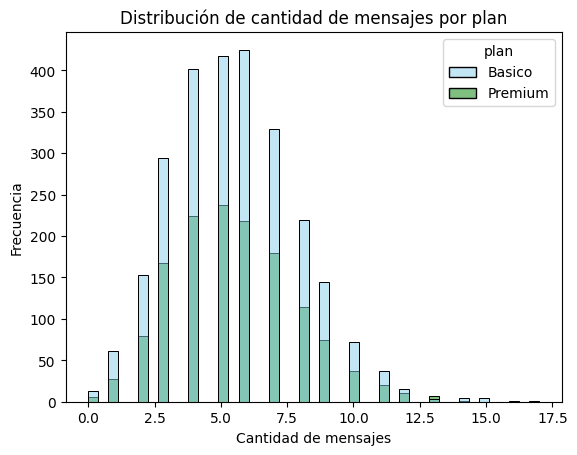

In [32]:
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], multiple='layer')
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
Tipo de distribución: aproximadamente simétrica con un ligero sesgo a la derecha (cola larga hacia valores altos, 12-17 mensajes con muy poca frecuencia), pico concentrado entre 4 y 6 mensajes.
Relación con plan: ambos planes siguen la misma forma de distribución y la misma proporción relativa (~65% Básico / ~35% Premium) en todos los rangos de cantidad de mensajes. No hay evidencia de que los usuarios Premium envíen más mensajes que los de Básico — el comportamiento de mensajería es similar entre planes, a pesar de que Premium incluye 5x más mensajes en su paquete (500 vs 100). Esto sugiere que el paquete de mensajes de Básico ya cubre ampliamente el uso real de la mayoría de los clientes.

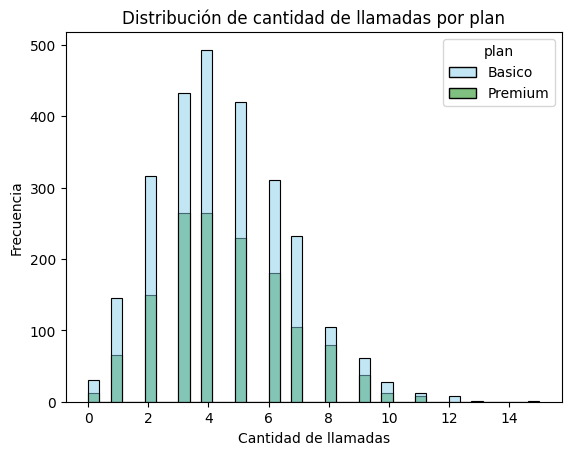

In [33]:
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], multiple='layer')
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
Tipo de distribución: aproximadamente simétrica con leve sesgo a la derecha (cola hacia 10-15 llamadas con muy baja frecuencia), pico concentrado entre 3 y 5 llamadas.
Relación con plan: al igual que con mensajes, ambos planes mantienen una proporción similar a lo largo de toda la distribución, sin diferencia notable en el comportamiento de llamadas entre Básico y Premium. Aunque Premium incluye 6x más minutos que Básico (600 vs 100), la cantidad de llamadas realizadas es prácticamente la misma — el volumen de llamadas no está impulsado por el tipo de plan contratado, sino que refleja un patrón de uso similar en toda la base de clientes.

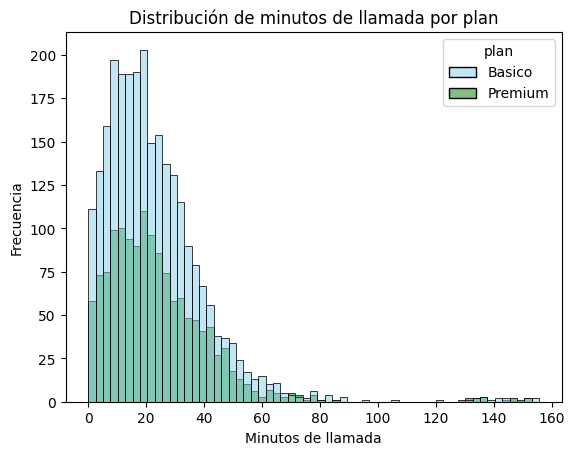

In [34]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], multiple='layer')
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
Tipo de distribución: claramente sesgada a la derecha (asimetría positiva) — la mayoría de los usuarios se concentra entre 0 y 40 minutos, con un pico alrededor de 15-20 minutos, pero hay una cola larga y dispersa que se extiende hasta 150+ minutos con frecuencias muy bajas. Este es el patrón más asimétrico de las cuatro variables analizadas.
Relación con plan: la proporción entre Básico y Premium se mantiene consistente a lo largo de la distribución (~65%/35%), sin que Premium muestre mayor consumo de minutos pese a tener 6x más minutos incluidos en su paquete. La cola larga hacia la derecha (usuarios con 100-155 minutos) es la que más adelante identificaremos como posibles outliers en el boxplot — son pocos casos, pero merecen revisión aparte ya que representan un comportamiento de uso muy por encima del promedio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

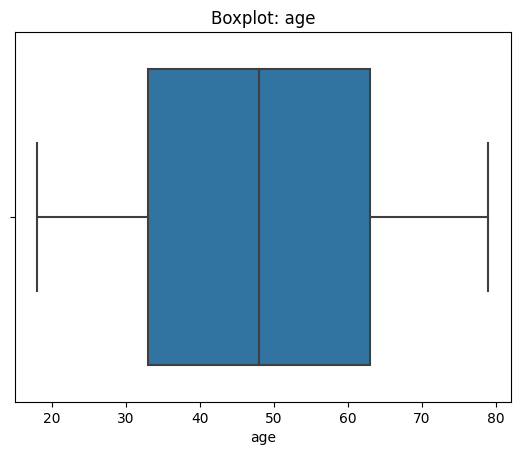

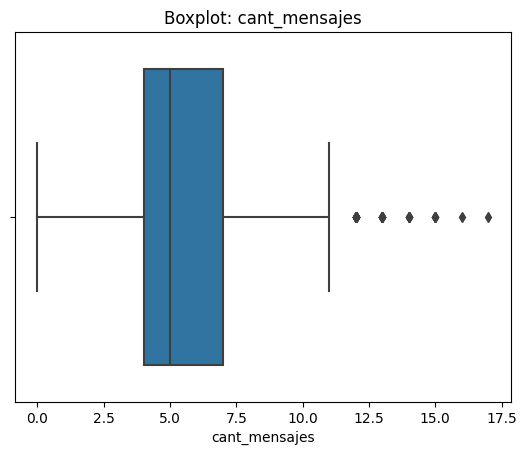

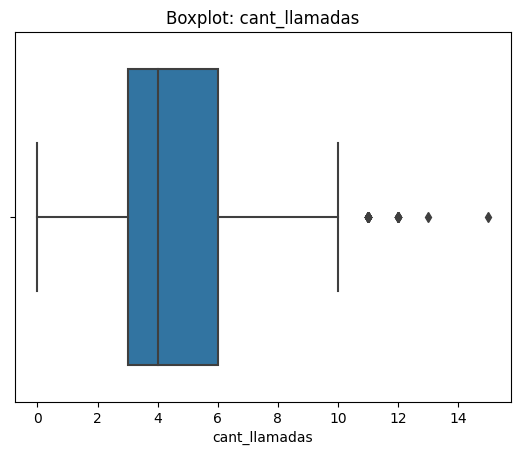

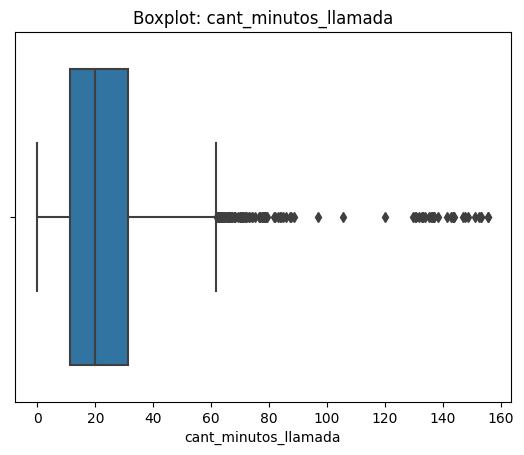

In [35]:

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 

Age: no presenta outliers. Los bigotes cubren todo el rango de datos (18-79), sin puntos sueltos fuera de ellos.
cant_mensajes: presenta outliers del lado derecho (valores entre ~12 y 17 mensajes aparecen como puntos fuera del bigote superior).
cant_llamadas: presenta outliers del lado derecho (valores entre ~11 y 15 llamadas aparecen como puntos fuera del bigote superior).
cant_minutos_llamada: presenta una cantidad considerable de outliers del lado derecho, con una cola larga que llega hasta ~155 minutos — es la variable con más outliers de las cuatro.

In [38]:
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f'{col}: límite superior = {limite_superior}')


cant_mensajes: límite superior = 11.5
cant_llamadas: límite superior = 10.5
cant_minutos_llamada: límite superior = 61.870000000000005


In [39]:

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes: mantener los outliers. Aunque el máximo (17) supera el límite IQR (11.5), la diferencia es moderada y representa un comportamiento de uso intenso pero plausible (un usuario que envía ~17 mensajes es alto pero no imposible). Eliminarlos reduciría información válida sobre el segmento de alto consumo.
cant_llamadas: mantener los outliers, por la misma razón — el máximo (15) frente al límite (10.5) no indica un valor imposible, sino usuarios con mayor actividad de llamadas. Es información de negocio relevante (posible segmento de alto uso a targetear con Premium).
cant_minutos_llamada: mantener, pero marcar para revisión. Aquí la brecha es mucho mayor (max 155.69 vs límite 61.87, casi 2.5x el límite), lo que sugiere una cola de usuarios de uso muy intensivo — probablemente clientes que hacen llamadas de larga duración de forma recurrente. No se eliminan porque no hay evidencia de que sean errores de captura (los valores son continuos y plausibles, no hay saltos abruptos ni valores absurdos como negativos o miles de minutos), pero este grupo merece atención especial: son candidatos claros para el segmento "Alto uso" y para estrategias de upselling a Premium o planes con más minutos incluidos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [41]:

user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [43]:

user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

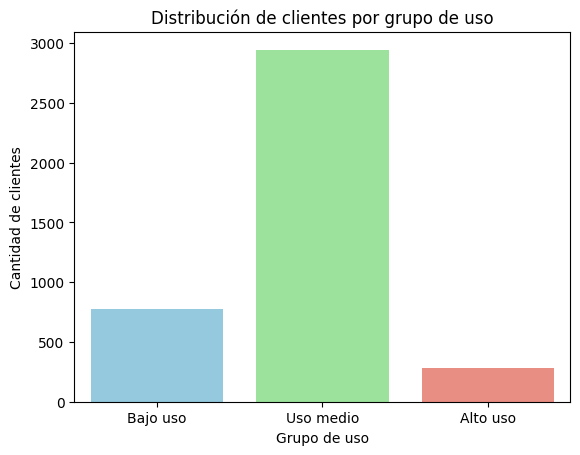

In [44]:
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette=['skyblue', 'lightgreen', 'salmon'])
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()

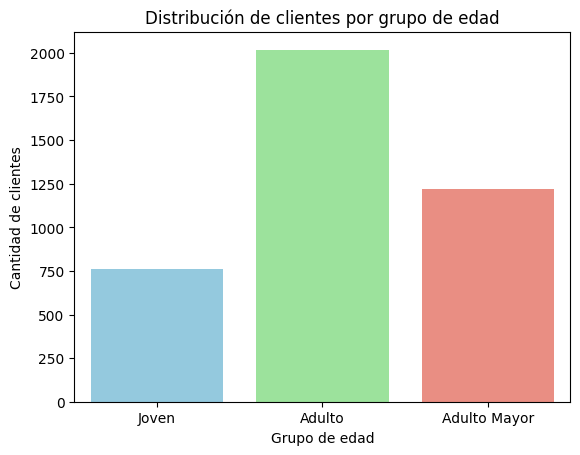

In [45]:
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette=['skyblue', 'lightgreen', 'salmon'])
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()


In [46]:
user_profile['churned'] = user_profile['churn_date'].notna()

print("Tasa de churn general:", user_profile['churned'].mean() * 100)
print()
print("Churn por plan:")
print(user_profile.groupby('plan')['churned'].mean() * 100)
print()
print("Churn por grupo_uso:")
print(user_profile.groupby('grupo_uso')['churned'].mean() * 100)
print()
print("Churn por grupo_edad:")
print(user_profile.groupby('grupo_edad')['churned'].mean() * 100)

Tasa de churn general: 11.65

Churn por plan:
plan
Basico     11.483622
Premium    11.957295
Name: churned, dtype: float64

Churn por grupo_uso:
grupo_uso
Alto uso     14.028777
Bajo uso     11.424904
Uso medio    11.484879
Name: churned, dtype: float64

Churn por grupo_edad:
grupo_edad
Adulto          12.487611
Adulto Mayor    10.965630
Joven           10.526316
Name: churned, dtype: float64



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
age: contenía el sentinel -999 (edad imposible), corregido con la mediana.
city: 565 registros sin ciudad válida (14.1% del total) — 469 nulos reales (11.7%) + 96 con el sentinel "?" (2.4%).
reg_date: 40 registros (1%) con año 2026, fecha imposible; marcados como nulos.
usage.date: 50 registros (0.125%) sin fecha, proporción insignificante.
duration/length: nulos estructurales (55.2% y 44.7%), explicados al 100% por el tipo de registro (call vs text), no representan un error real.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Por edad: Adulto (50.5%), Adulto Mayor (30.6%), Joven (19%). No hay diferencia relevante en tipo de plan ni en churn entre estos grupos (churn: Adulto 12.5%, Adulto Mayor 11%, Joven 10.5% — variación menor).
Por nivel de uso: Uso medio (73.6%), Bajo uso (19.5%), Alto uso (7%). El comportamiento de mensajes y llamadas es prácticamente idéntico entre planes Básico y Premium, sin importar el grupo de edad.
 
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
El segmento "Uso medio" (73.6% de la base) es el más valioso por volumen: es el grueso del negocio y su churn (11.5%) está en línea con el promedio general (11.65%), es decir, es una base estable.
El segmento "Alto uso" (7% de la base), aunque pequeño, es el de mayor consumo — y por eso el más rentable por cliente. Sin embargo, es también el que más churnea (14% vs 11.65% promedio), lo cual lo hace valioso pero en riesgo: es el segmento donde perder un cliente cuesta más.
No se identifica un segmento etario más valioso que otro — la edad no muestra relación clara con plan, uso o churn en estos datos.
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
cant_mensajes y cant_llamadas: outliers moderados (máximos de 17 y 15 frente a límites IQR de 11.5 y 10.5). Se mantuvieron porque representan uso alto pero plausible, no errores.
cant_minutos_llamada: el patrón más marcado — máximo de 155.69 minutos frente a un límite IQR de solo 61.87 (casi 2.5x). Implica un grupo pequeño de clientes con consumo de voz muy superior al resto, un nicho identificable de alto valor en minutos, potencial candidato a un plan de mayor consumo o a fuga hacia la competencia si su plan actual no cubre su necesidad real.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Priorizar retención en el segmento "Alto uso": es el más rentable pero con mayor churn (14%); una campaña de fidelización o revisión de precio/beneficios dirigida a este grupo tiene el mayor impacto potencial en ingresos retenidos.
Dado que Básico y Premium consumen mensajes y llamadas de forma casi idéntica, evaluar si Premium está sobredimensionado — considerar un plan intermedio ajustado al uso real del segmento "Uso medio" (73.6% de la base), que hoy probablemente paga de más o de menos según el plan que eligió sin relación clara con su consumo.
Crear una oferta específica para el nicho de alto consumo de minutos (outliers en cant_minutos_llamada, hasta 155 min) antes de que decidan cambiarse a la competencia por falta de un plan que se ajuste a su uso real.
Corregir el problema de captura de city (14.1% de datos inválidos) para habilitar análisis geográfico en futuras iteraciones, hoy una variable desaprovechada por mala calidad de origen.

✍️ **Escribe aquí tu análisis ejecutivo:**
Al iniciar este análisis encontramos varios problemas de calidad que había que resolver antes de sacar cualquier conclusión. La columna de edad traía un valor centinela de -999 que distorsionaba por completo el promedio, así que lo reemplazamos por la mediana. La ciudad no estaba disponible para el 14% de los clientes, entre registros vacíos y un valor "?" que claramente era un error de captura. Cuarenta clientes, un 1% de la base, tenían una fecha de registro en 2026, algo imposible si los datos llegan hasta 2024, así que se marcaron como nulos. Y los campos de duración de llamada y longitud de mensaje resultaron tener muchos vacíos, pero eso no era un error: simplemente una llamada no tiene longitud de mensaje y viceversa, así que se dejaron tal cual.
Con los datos ya limpios, identificamos que la mayoría de los clientes de ConnectaTel son adultos entre 30 y 60 años, seguidos de adultos mayores y, en menor proporción, jóvenes. La edad, sin embargo, no parece influir mucho en el comportamiento: el tipo de plan contratado y la tasa de cancelación se mantienen bastante parejos entre los tres grupos etarios. Donde sí encontramos una diferencia más clara fue en el nivel de uso. Casi tres cuartas partes de los clientes se ubican en un uso medio de la red, uno de cada cinco tiene un uso bajo, y solo un 7% se puede considerar de alto uso.
Ese pequeño grupo de alto uso es, en realidad, el más interesante para el negocio. Son los clientes que más consumen y por lo tanto los más rentables, pero también son los que más cancelan, con una tasa de cancelación de 14% frente al 11.65% general. Eso llama la atención porque uno esperaría que un cliente que usa mucho el servicio esté más satisfecho, no menos. También notamos que un grupo reducido de usuarios hace llamadas mucho más largas que el resto, con algunos casos que llegan a superar los 150 minutos cuando lo típico ronda los 20. Este patrón no parece un error de los datos, sino un comportamiento real de un nicho de clientes con una necesidad de voz distinta al promedio.
Con todo esto en mente, creemos que ConnectaTel debería enfocar sus esfuerzos de retención en el segmento de alto uso, ya que ahí está el mayor riesgo de perder ingresos importantes. También vale la pena revisar si el plan Premium realmente está justificando su precio, porque en la práctica los clientes de ambos planes envían mensajes y hacen llamadas de forma muy similar, lo que sugiere que muchos podrían estar pagando por beneficios que no usan. Ese grupo de clientes con llamadas muy largas merece una oferta pensada específicamente para ellos, antes de que la falta de un plan adecuado los empuje hacia la competencia. Por último, sería importante mejorar la forma en que se captura la ciudad de cada cliente, porque hoy esa información no se puede aprovechar y podría ayudar a entender mejor las diferencias regionales en el consumo.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
La edad de los clientes tenía un valor imposible de -999 en algunos registros, lo corregimos usando la mediana de las edades válidas.
La ciudad no estaba disponible para el 14% de los clientes, entre casillas vacías y un valor "?" que era claramente un error de captura.
Cuarenta clientes, un 1% del total, tenían una fecha de registro en el año 2026, algo imposible ya que los datos solo cubren hasta 2024, así que se marcaron como no disponibles.
Los campos de duración de llamada y longitud de mensaje tenían muchos vacíos, pero eso resultó ser algo normal del diseño de los datos: una llamada no tiene longitud de mensaje y un mensaje no tiene duración de llamada, así que se dejaron sin modificar.


🔍 **Segmentos por Edad**
La mayoría de los clientes son adultos entre 30 y 60 años, seguidos de adultos mayores y, en menor medida, jóvenes.
La edad no parece influir demasiado en el comportamiento del cliente, ya que tanto el tipo de plan como la tasa de cancelación se mantienen muy similares entre los tres grupos.

📊 **Segmentos por Nivel de Uso**

Casi tres cuartas partes de los clientes tienen un nivel de uso medio, uno de cada cinco tiene un uso bajo y solo el 7% se considera de alto uso.
El grupo de alto uso es el más rentable, pero también el que más cancela, con un 14% de cancelación frente al 11.65% del promedio general.


➡️ Esto sugiere que el comportamiento de cancelación en ConnectaTel no depende tanto de la edad o del plan contratado, sino que está más relacionado con el nivel de uso. El hecho de que los clientes más activos sean también los que más se van es una señal de que algo en su experiencia no los está reteniendo, a pesar de ser el grupo más valioso.


💡 **Recomendaciones**
Enfocar los esfuerzos de retención en el segmento de alto uso, ya que es donde ConnectaTel corre mayor riesgo de perder ingresos importantes.
Revisar si el plan Premium realmente se justifica frente al Básico, porque en la práctica ambos grupos de clientes usan la red de forma muy parecida.
Diseñar una oferta pensada para los clientes con llamadas mucho más largas que el promedio, antes de que la falta de un plan adecuado los lleve a buscar otra compañía.
Mejorar la forma en que se recolecta la ciudad de cada cliente, para poder aprovechar esa información en futuros análisis regionales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`